In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



In [16]:
df=pd.read_csv('meets.csv')
print(df)

      MeetID                   MeetPath Federation        Date MeetCountry  \
0          0             365strong/1601  365Strong  2016-10-29         USA   
1          1             365strong/1602  365Strong  2016-11-19         USA   
2          2             365strong/1603  365Strong  2016-07-09         USA   
3          3             365strong/1604  365Strong  2016-06-11         USA   
4          4             365strong/1605  365Strong  2016-04-10         USA   
...      ...                        ...        ...         ...         ...   
8477    8477            xpc/2015-finals        XPC  2015-03-06         USA   
8478    8478  xpc/2016-bench-freak-show        XPC  2016-03-04         USA   
8479    8479      xpc/2016-elite-finals        XPC  2016-03-04         USA   
8480    8480        xpc/2016-pro-finals        XPC  2016-03-05         USA   
8481    8481            xpc/2017-finals        XPC  2017-03-03         USA   

     MeetState   MeetTown                                      

In [17]:
df.describe()

,MeetID
count,8482.000000
mean,4240.500000
std,2448.686825
min,0.000000
25%,2120.250000
50%,4240.500000
75%,6360.750000
max,8481.000000


In [18]:
df.columns

Index(['MeetID', 'MeetPath', 'Federation', 'Date', 'MeetCountry', 'MeetState',
       'MeetTown', 'MeetName'],
      dtype='object')

In [19]:
df.info

<bound method DataFrame.info of       MeetID                   MeetPath Federation        Date MeetCountry  \
0          0             365strong/1601  365Strong  2016-10-29         USA   
1          1             365strong/1602  365Strong  2016-11-19         USA   
2          2             365strong/1603  365Strong  2016-07-09         USA   
3          3             365strong/1604  365Strong  2016-06-11         USA   
4          4             365strong/1605  365Strong  2016-04-10         USA   
...      ...                        ...        ...         ...         ...   
8477    8477            xpc/2015-finals        XPC  2015-03-06         USA   
8478    8478  xpc/2016-bench-freak-show        XPC  2016-03-04         USA   
8479    8479      xpc/2016-elite-finals        XPC  2016-03-04         USA   
8480    8480        xpc/2016-pro-finals        XPC  2016-03-05         USA   
8481    8481            xpc/2017-finals        XPC  2017-03-03         USA   

     MeetState   MeetTown      

In [20]:
df.duplicated()
# Count total duplicate rows
df.duplicated().sum()

np.int64(0)

In [21]:
# Remove duplicates and keep the first occurrence
df_cleaned = df.drop_duplicates()

# Remove duplicates based on specific columns (e.g., 'MeetID')
df_cleaned = df.drop_duplicates(subset=['MeetID'], keep='first')

In [22]:
# Count missing values per column
df.isnull().sum()

MeetID            0
MeetPath          0
Federation        0
Date              0
MeetCountry       0
MeetState      2986
MeetTown       1509
MeetName          0
dtype: int64

In [23]:
# Drop rows where ANY column has a missing value
df_dropped = df.dropna()

# Drop rows only if missing values are in a specific column
df_dropped = df.dropna(subset=['MeetState'])

In [29]:
# Fill with a constant value or string
df['MeetState'] = df['MeetState'].fillna('Unknown')



In [30]:
# Fill with a constant value or string
df['MeetTown'] = df['MeetTown'].fillna('Unknown')

In [31]:
# Save to the same folder
df.to_csv('meets.csv', index=False)
df.to_csv(r'D:\yash project\meets.csv', index=False)

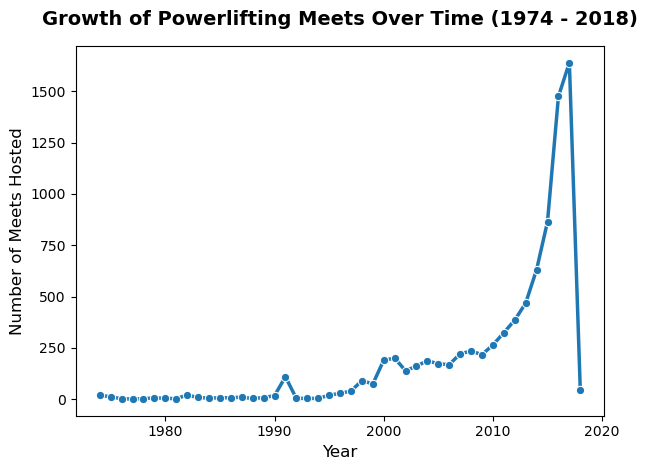

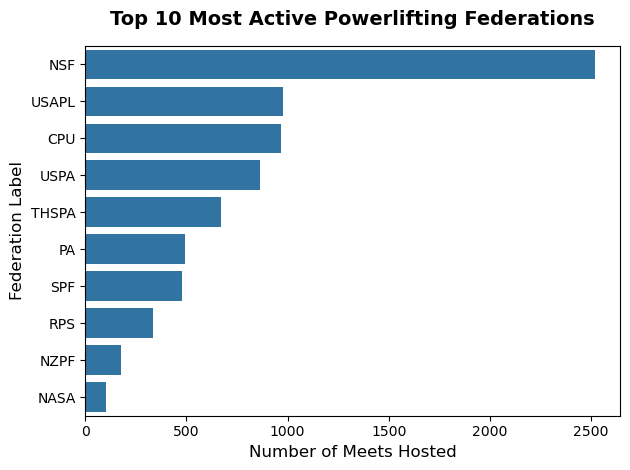

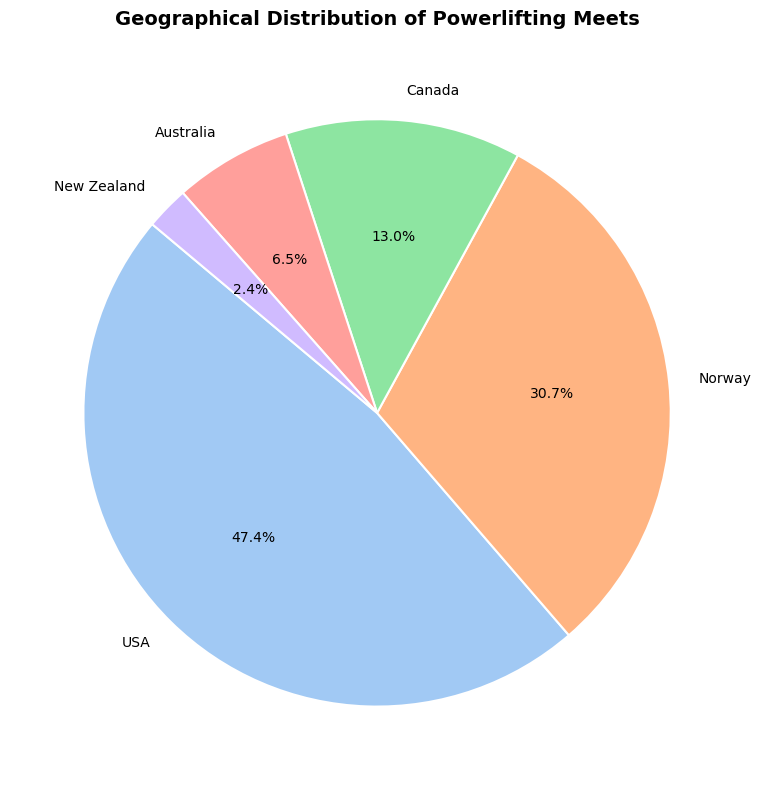

In [34]:

# 1. Load and clean the data

# Convert Date to datetime and extract Year
df['Date'] = pd.to_datetime(df['Date'])
df['Year'] = df['Date'].dt.year


# CHART 1: Tournament Growth Timeline (Trend)
# ==========================================
plt.figure()
# Group by year and count meets, filtering out any incomplete future placeholder dates
yearly_meets = df[df['Year'] <= 2018].groupby('Year')['MeetID'].count().reset_index()

sns.lineplot(data=yearly_meets, x='Year', y='MeetID', marker='o', color='#1f77b4', linewidth=2.5)
plt.title('Growth of Powerlifting Meets Over Time (1974 - 2018)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Meets Hosted', fontsize=12)
plt.tight_layout()
plt.show()

# ==========================================
# CHART 2: Top 10 Most Active Federations
# ==========================================
plt.figure()
top_federations = df['Federation'].value_counts().iloc[:10].reset_index()
top_federations.columns = ['Federation', 'Meet Count']

sns.barplot(data=top_federations, x='Meet Count', y='Federation')
plt.title('Top 10 Most Active Powerlifting Federations', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Number of Meets Hosted', fontsize=12)
plt.ylabel('Federation Label', fontsize=12)
plt.tight_layout()
plt.show()

# ==========================================
# CHART 3: Country Market Share (Top 5 Countries)
# ==========================================
plt.figure(figsize=(8, 8))
country_counts = df['MeetCountry'].value_counts().iloc[:5]

# Using standard Matplotlib for a clean storytelling pie chart
plt.pie(
    country_counts, 
    labels=country_counts.index, 
    autopct='%1.1f%%', 
    startangle=140, 
    colors=sns.color_palette('pastel')[:5],
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
plt.title('Geographical Distribution of Powerlifting Meets', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()
